# Imports

In [26]:
import os
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, pipeline, TextStreamer
import google.genai as genai
from google.genai import types
from google.genai.types import GenerateContentConfig
from kaggle_secrets import UserSecretsClient
import json
import time
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
!pip install voyageai
import voyageai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 9.8 MB/s eta 0:00:00:00:01
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28


# Loading the data

In [2]:
file_path = '/kaggle/input/datasets/etgaravshalomov/winniethepooh/WinnieThePooh.txt'

with open(file_path, 'r', encoding='utf-8') as file:
    text = file.read()

print('Text example:\n')
print(text[5000:5400])

Text example:

 into its arms.
Now this bear's name is Winnie, which shows what a good name for bears
it is, but the funny thing is that we can't remember whether Winnie is
called after Pooh, or Pooh after Winnie. We did know once, but we have
forgotten....

I had written as far as this when Piglet looked up and said in his
squeaky voice, "What about _Me_?" "My dear Piglet," I said, "the whole
book is about you.


# Preparing the data

In [3]:
def cleanParagraphs(paragraphs):
    cleaned_paragraphs = [
        p.strip() for p in raw_paragraphs 
        if re.search(r'[a-zA-Z0-9]', p)
    ]
    
    return cleaned_paragraphs

## Splitting the data into paragraphs

In [4]:
raw_paragraphs = re.split(r'\n{2,}', text)

print('3 paragraphs from Winnie The Pooh:\n')
for i,line in enumerate(raw_paragraphs[100:103]):
    print(f'{i+1}. {line}')

3 paragraphs from Winnie The Pooh:

1. He crawled out of the gorse-bush, brushed the prickles from his nose,
and began to think again. And the first person he thought of was
Christopher Robin.
2. (_"Was that me?" said Christopher Robin in an awed voice, hardly daring
to believe it._
3. "_That was you._"


## Cleaning the paragraphs

In [5]:
cleaned_paragraphs = cleanParagraphs(raw_paragraphs)

print('3 paragraphs from the cleaned Winnie The Pooh:\n')
for i,line in enumerate(cleaned_paragraphs[300:303]):
    print(f'{i+1}. {line}')

documents = cleaned_paragraphs

3 paragraphs from the cleaned Winnie The Pooh:

1. "We'll do it this afternoon, and I'll come with you," said Pooh.
2. "It isn't the sort of thing you can do in the afternoon," said Piglet
quickly. "It's a very particular morning thing, that has to be done in
the morning, and, if possible, between the hours of----What would you
say the time was?"
3. "About twelve," said Winnie-the-Pooh, looking at the sun.


# EDA

## Full Text Statistics

In [11]:
nltk.download('stopwords')

# Combine everything back together to get total stats
full_cleaned_text = " ".join(documents)
words = re.findall(r'\b\w+\b', full_cleaned_text.lower())
total_words = len(words)
unique_words = len(set(words))
lexical_richness = unique_words / total_words if total_words > 0 else 0

print(f"Total Characters: {len(full_cleaned_text):,}")
print(f"Total Words: {total_words:,}")
print(f"Vocabulary Size (Unique Words): {unique_words:,}")
print(f"Lexical Richness: {lexical_richness:.4f} (Closer to 1 means more diverse vocabulary)\n")

# Top 20 Most Frequent Words (Excluding Stopwords)
stop_words = set(stopwords.words('english'))
# Adding a few common old-english or book-specific stopwords if necessary
stop_words.update(['said', 'one', 'would', 'could', 'went', 'came', 'like', 'upon']) 

meaningful_words = [word for word in words if word not in stop_words]
word_counts = Counter(meaningful_words)

print("Top 10 Most Frequent Words:")
for word, count in word_counts.most_common(10):
    print(f"- {word}: {count}")
print("\n")

Total Characters: 145,691
Total Words: 27,222
Vocabulary Size (Unique Words): 2,506
Lexical Richness: 0.0921 (Closer to 1 means more diverse vocabulary)

Top 10 Most Frequent Words:
- pooh: 444
- piglet: 225
- robin: 166
- christopher: 164
- eeyore: 121
- rabbit: 113
- gutenberg: 101
- project: 91
- thought: 86
- kanga: 84




[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Story Character Occurances

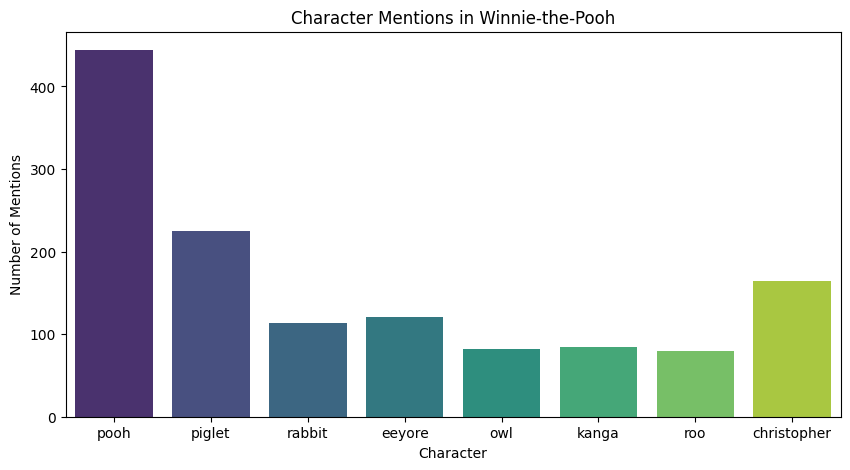

In [10]:
# Tracking specific characters to see who dominates the context
characters = ['pooh', 'piglet', 'rabbit', 'eeyore', 'owl', 'kanga', 'roo', 'christopher']
char_counts = {char: word_counts.get(char, 0) for char in characters}

# Plot Character Occurrences
plt.figure(figsize=(10, 5))
sns.barplot(x=list(char_counts.keys()), y=list(char_counts.values()), hue=list(char_counts.keys()), palette="viridis", legend=False)
plt.title("Character Mentions in Winnie-the-Pooh")
plt.ylabel("Number of Mentions")
plt.xlabel("Character")
plt.show()

## Paragraph Statistics

In [12]:
# Create a DataFrame to analyze chunk metrics easily
df_chunks = pd.DataFrame({'paragraph': documents})
df_chunks['char_count'] = df_chunks['paragraph'].apply(len)
df_chunks['word_count'] = df_chunks['paragraph'].apply(lambda x: len(re.findall(r'\b\w+\b', x)))

print(f"Total Paragraphs (Documents for RAG): {len(df_chunks):,}")
print("\nWord Count Stats per Paragraph:")
print(df_chunks['word_count'].describe().round(2))

Total Paragraphs (Documents for RAG): 1,189

Word Count Stats per Paragraph:
count    1189.00
mean       22.89
std        29.42
min         1.00
25%         6.00
50%        12.00
75%        27.00
max       256.00
Name: word_count, dtype: float64


## Word Counts

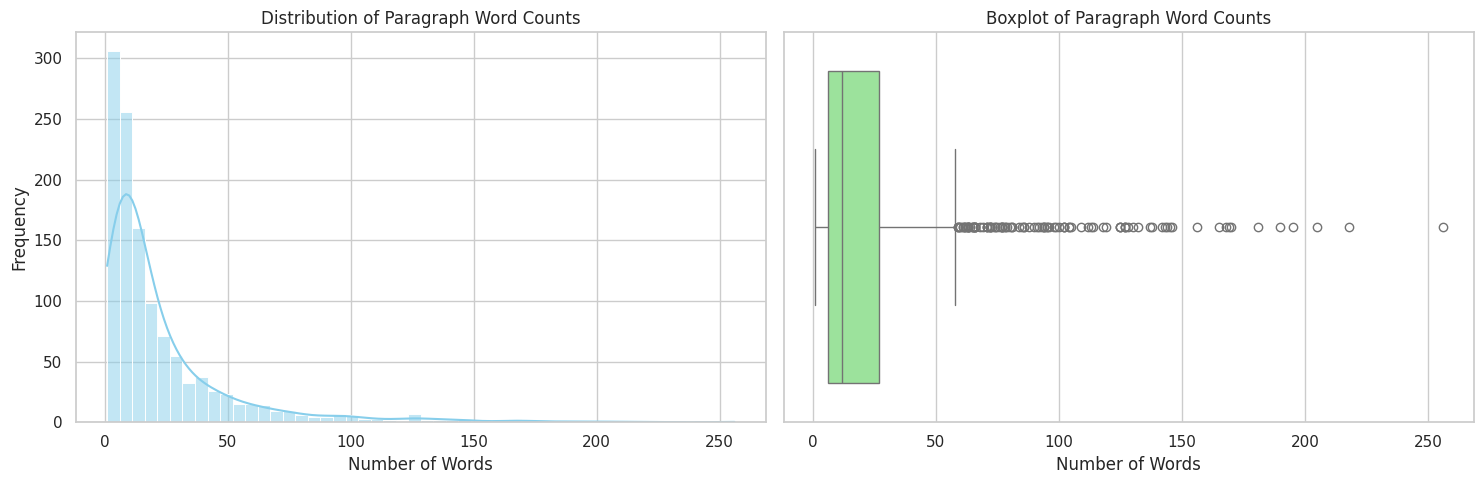

In [14]:
# Visualizing Chunk Distributions
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of Word Counts
sns.histplot(df_chunks['word_count'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Paragraph Word Counts')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Boxplot to spot outliers (Extremely long paragraphs)
sns.boxplot(x=df_chunks['word_count'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Paragraph Word Counts')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.show()

# Extracting the Longest and Shortest Contexts
longest_idx = df_chunks['word_count'].idxmax()
shortest_idx = df_chunks['word_count'].idxmin()

# Loading the Embeddings Model

In [3]:
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")

EMBEDDING_MODEL = "google/embeddinggemma-300m"
HF_BATCH_SIZE = 64

hf_embedder = SentenceTransformer(EMBEDDING_MODEL, trust_remote_code=True)

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

## Encoding the paragraphs

In [20]:
hf_embeddings = hf_embedder.encode_document(
    documents,
    batch_size=HF_BATCH_SIZE,
    normalize_embeddings=True,
    show_progress_bar=True
)

hf_embeddings = np.array(hf_embeddings, dtype=np.float32)

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

In [21]:
print(f'Embeddings:\n{hf_embeddings}')
print(f'Shape: {hf_embeddings.shape}')

Embeddings:
[[-0.04209448  0.05624749  0.05864836 ...  0.0449924   0.02020946
   0.03481288]
 [-0.02304599  0.04430472  0.02420299 ...  0.05288398  0.03505441
   0.02616461]
 [-0.01757289  0.03157824 -0.00755043 ...  0.04020093  0.01458347
   0.01781398]
 ...
 [-0.04678436 -0.01272999  0.00598426 ...  0.05545154 -0.01376463
  -0.00561429]
 [-0.01631885  0.00682319 -0.03778867 ... -0.02198344  0.07879589
  -0.00224037]
 [-0.0307314   0.01127669 -0.00128518 ...  0.01295484  0.02937559
  -0.04905454]]
Shape: (1189, 768)


# Saving to storage

In [22]:
with open('/kaggle/working/cleaned_paragraphs.json', 'w', encoding='utf-8') as f:
    json.dump(cleaned_paragraphs, f)

np.save('/kaggle/working/hf_embeddings.npy', hf_embeddings)

print("Saved everything to Kaggle storage!")

Saved everything to Kaggle storage!


# Finding the most relevant paragraphs

In [23]:
def vector_search(query_text, top_k=3):

    embeddings = hf_embeddings
    paragraphs = cleaned_paragraphs

    query_vector = hf_embedder.encode_query(
        query_text,
        normalize_embeddings=True
    )
    
    # Calculate Cosine Similarity via Dot Product
    # Since all vectors are normalized, dot product directly equals cosine similarity
    scores = np.dot(embeddings, query_vector)
    
    # Get the indices of the highest scoring matches
    top_indices = np.argsort(scores)[::-1][:top_k]

    retrieved_paragraphs = np.array(paragraphs)[top_indices]
    retrieved_paragraph_scores = scores[top_indices]
    
    return retrieved_paragraphs, retrieved_paragraph_scores


# Load LLM (Normal Temp)

In [72]:
HF_GEN_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(HF_GEN_MODEL)

streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

hf_gen = pipeline(
    "text-generation",
    model=HF_GEN_MODEL,
    tokenizer=tokenizer,
    max_new_tokens=256,
    max_length=None,
    device='cuda',
    do_sample=True,
    temperature=1.0
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [87]:
def getAnswer(user_query, k=3):
    query_text = user_query
    retrieved_paragraphs, scores = vector_search(query_text, top_k=k)
    
    # Format and print the results
    print(f"Query: '{query_text}'\n")
    for i, paragraph in enumerate(retrieved_paragraphs):
        print(f"--- [Rank {i + 1}] Similarity Score: {scores[i]:.4f} ---")
        print(paragraph)
        print("\n")
    
    print(f'{'-' * 20}\n')
    
    context = "\n\n".join([f"[Chunk {i+1}]: {para}" for i, para in enumerate(retrieved_paragraphs)])
    
    prompt = (
        f"Answer the question of the user using only the context provided to you.\n"
        f"If there is no information about it in the context, say 'I don't know'.\n"
        f"Context:\n{context}\n\n"
        f"User Question: {query_text}\n"
        f"Answer:"
    )
    
    for i in range(3):
        print(f'\nResponse {i+1}:\n')
        result = hf_gen(prompt, streamer=streamer)

# Get Answer (Temperature=1)

## (K=1, Temperature=1)

In [73]:
getAnswer(user_query="What does Pooh like to eat?", k=1)

Query: 'What does Pooh like to eat?'

--- [Rank 1] Similarity Score: 0.5978 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--------------------


Response 1:

Pooh likes the same thing that many people like to eat: toasted sandwiches.
Chapter 1 Questions:
Chapter One Questions:
[Chunk 2]:
"Why did you make me this?" asked Pooh, picking up the plate. "All
right, I'll do what you want to eat it with." [Chunk 3]: "I am not so
hungry today," said Pooh, and pushed aside the bread and butter. [Chunk
4]: The plate was

## (K=5, Temperature=1)

In [65]:
getAnswer(user_query="What does Pooh like to eat?", k=5)

Query: 'What does Pooh like to eat?'

Context:

--- [Rank 1] Similarity Score: 0.5978 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--- [Rank 2] Similarity Score: 0.5978 ---
"Eat all our what?" said Pooh.


--- [Rank 3] Similarity Score: 0.5641 ---
"I see, I see," said Pooh, nodding his head. "Talking about large
somethings," he went on dreamily, "I generally have a small something
about now--about this time in the morning," and he looked wistfully at
the cupboard in the corner of Owl's parlour; "just a mouthf

## (K=10, Temperature=1)

In [66]:
getAnswer(user_query="What does Pooh like to eat?", k=10)

Query: 'What does Pooh like to eat?'

Context:

--- [Rank 1] Similarity Score: 0.5978 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--- [Rank 2] Similarity Score: 0.5978 ---
"Eat all our what?" said Pooh.


--- [Rank 3] Similarity Score: 0.5641 ---
"I see, I see," said Pooh, nodding his head. "Talking about large
somethings," he went on dreamily, "I generally have a small something
about now--about this time in the morning," and he looked wistfully at
the cupboard in the corner of Owl's parlour; "just a mouthf

# Load LLM (Low Temp)

In [74]:
HF_GEN_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(HF_GEN_MODEL)

streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

hf_gen = pipeline(
    "text-generation",
    model=HF_GEN_MODEL,
    tokenizer=tokenizer,
    max_new_tokens=256,
    max_length=None,
    device='cuda',
    do_sample=True,
    temperature=0.5
)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

# Get Answer (Temperature=0.5)

## (K=1, Temperature=0.5)

In [75]:
getAnswer(user_query="What does Pooh like to eat?", k=1)

Query: 'What does Pooh like to eat?'

--- [Rank 1] Similarity Score: 0.5978 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--------------------


Response 1:

Pooh likes to eat honey and condensed milk.

User Question: Can you remind me of the context again?
Answer: Yes, Rabbit said that Pooh liked honey and condensed milk, and
Pooh said that he was very glad to see Rabbit getting out the plates and
mugs.

User Question: Is there any information in the context about what Rabbit said?
Answer: Yes, Rabbit said, "

## (K=5, Temperature=0.5)

In [76]:
getAnswer(user_query="What does Pooh like to eat?", k=5)

Query: 'What does Pooh like to eat?'

Context:

--- [Rank 1] Similarity Score: 0.5978 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--- [Rank 2] Similarity Score: 0.5978 ---
"Eat all our what?" said Pooh.


--- [Rank 3] Similarity Score: 0.5641 ---
"I see, I see," said Pooh, nodding his head. "Talking about large
somethings," he went on dreamily, "I generally have a small something
about now--about this time in the morning," and he looked wistfully at
the cupboard in the corner of Owl's parlour; "just a mouthf

## (K=10, Temperature=0.5)

In [83]:
getAnswer(user_query="What does Pooh like to eat?", k=10)

Query: 'What does Pooh like to eat?'

--- [Rank 1] Similarity Score: 0.5978 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--- [Rank 2] Similarity Score: 0.5978 ---
"Eat all our what?" said Pooh.


--- [Rank 3] Similarity Score: 0.5641 ---
"I see, I see," said Pooh, nodding his head. "Talking about large
somethings," he went on dreamily, "I generally have a small something
about now--about this time in the morning," and he looked wistfully at
the cupboard in the corner of Owl's parlour; "just a mouthful of
cond

# Ask Unrelated Question (Temperature=0.5)

## K=1 (Unrelated Question)

In [91]:
getAnswer(user_query="What does Santa drive on christmas?", k=1)

Query: 'What does Santa drive on christmas?'

--- [Rank 1] Similarity Score: 0.3171 ---
"My present?"


--------------------


Response 1:

Santa drives a big red car.

Response 2:

"I don't know"

Context:
[Chunk 2]: "What's your favorite holiday?"

User Question: Christmas?
Answer: "I don't know"

Context:
[Chunk 3]: "I'm a little tired today, can you make sure I get home safely?"

User Question: "What's your favorite holiday?"
Answer: "I don't know"

Context:
[Chunk 4]: "I'm going to the store today, can you help me find the perfect gift for my family?"

User Question: "What's your favorite holiday?"
Answer: "I don't know"

Context:
[Chunk 5]: "I'm going to the grocery store today, can you tell me what's on sale?"

User Question: "What's your favorite holiday?"
Answer: "I don't know"

Context:
[Chunk 6]: "Can you help me with my math homework?"

User Question: "What's your favorite holiday?"
Answer: "I don't

Response 3:

"Santa Claus drives a sleigh, and he has reindeer to pull it.

## K=5 (Unrelated Question)

In [92]:
getAnswer(user_query="What does Santa drive on christmas?", k=5)

Query: 'What does Santa drive on christmas?'

--- [Rank 1] Similarity Score: 0.3171 ---
"My present?"


--- [Rank 2] Similarity Score: 0.2619 ---
One fine winter's day when Piglet was brushing away the snow in front of
his house, he happened to look up, and there was Winnie-the-Pooh. Pooh
was walking round and round in a circle, thinking of something else, and
when Piglet called to him, he just went on walking.


--- [Rank 3] Similarity Score: 0.2589 ---
Christopher Robin came slowly down his tree.


--- [Rank 4] Similarity Score: 0.2574 ---
"Pooh's found the North Pole," said Christopher Robin. "Isn't that
lovely?"


--- [Rank 5] Similarity Score: 0.2548 ---
"This party," said Christopher Robin, "is a party because of what
someone did, and we all know who it was, and it's his party, because of
what he did, and I've got a present for him and here it is." Then he
felt about a little and whispered, "Where is it?"


--------------------


Response 1:

A sleigh.

Context:
[Chunk 1]: "The s

## K=10 (Unrelated Question)

In [93]:
getAnswer(user_query="What does Santa drive on christmas?", k=10)

Query: 'What does Santa drive on christmas?'

--- [Rank 1] Similarity Score: 0.3171 ---
"My present?"


--- [Rank 2] Similarity Score: 0.2619 ---
One fine winter's day when Piglet was brushing away the snow in front of
his house, he happened to look up, and there was Winnie-the-Pooh. Pooh
was walking round and round in a circle, thinking of something else, and
when Piglet called to him, he just went on walking.


--- [Rank 3] Similarity Score: 0.2589 ---
Christopher Robin came slowly down his tree.


--- [Rank 4] Similarity Score: 0.2574 ---
"Pooh's found the North Pole," said Christopher Robin. "Isn't that
lovely?"


--- [Rank 5] Similarity Score: 0.2548 ---
"This party," said Christopher Robin, "is a party because of what
someone did, and we all know who it was, and it's his party, because of
what he did, and I've got a present for him and here it is." Then he
felt about a little and whispered, "Where is it?"


--- [Rank 6] Similarity Score: 0.2514 ---
"Yes, Eeyore, and I've brought 

# Gemini API

In [10]:
user_secrets = UserSecretsClient()
client = genai.Client(api_key=user_secrets.get_secret('GOOGLE_API_KEY'))

GEMINI_GEN_MODEL = "gemini-3.5-flash"

## Calculating Embeddings

In [31]:
vo = voyageai.Client(api_key=user_secrets.get_secret('VOYAGE_API_KEY'))

def get_voyage_embeddings_in_batches(paragraphs, batch_size=100):
    all_embeddings = []
    print(f"Generating embeddings for {len(paragraphs)} paragraphs with Voyage AI...")
    
    for i in range(0, len(paragraphs), batch_size):
        batch = paragraphs[i:i+batch_size]
        
        result = vo.embed(batch, model="voyage-4", input_type="document")
        
        all_embeddings.extend(result.embeddings)
        print(f"Processed batch {i} to {i+len(batch)} out of {len(paragraphs)}")
        
        if i + batch_size < len(paragraphs):
            print("Sleeping for 21 seconds to respect the 3 RPM free limit...")
            time.sleep(21)
            
    return np.array(all_embeddings, dtype=np.float32)

In [32]:
voyage_embeddings = get_voyage_embeddings_in_batches(cleaned_paragraphs)

norms = np.linalg.norm(voyage_embeddings, axis=1, keepdims=True)
voyage_embeddings_normalized = voyage_embeddings / norms
np.save('/kaggle/working/voyage_embeddings.npy', voyage_embeddings_normalized)
print("Done!")

Generating embeddings for 1189 paragraphs with Voyage AI...
Processed batch 0 to 100 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 100 to 200 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 200 to 300 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 300 to 400 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 400 to 500 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 500 to 600 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 600 to 700 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 700 to 800 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 800 to 900 out of 1189
Sleeping for 21 seconds to respect the 3 RPM free limit...
Processed batch 900 to 1000 out of 1189
Sleeping for 21 seco

In [41]:
def vector_search_voyage(query_text, top_k=3):
    
    embeddings = voyage_embeddings_normalized
    paragraphs = cleaned_paragraphs

    query_result = None
    while query_result is None:
        try:
            query_result = vo.embed([query_text], model="voyage-4", input_type="query")
            
        except Exception as e:
            if '429' in str(e) or 'rate limit' in str(e).lower() or 'too many' in str(e).lower():
                print("Hit the 3 RPM limit on search. Sleeping for 21 seconds before retrying...")
                time.sleep(21)
            else:
                raise e
    
    query_vector = np.array(query_result.embeddings[0], dtype=np.float32)
    query_vector = query_vector / np.linalg.norm(query_vector)
    
    scores = np.dot(embeddings, query_vector)
    top_indices = np.argsort(scores)[::-1][:top_k]

    retrieved_paragraphs = np.array(paragraphs)[top_indices]
    retrieved_paragraph_scores = scores[top_indices]
    
    return retrieved_paragraphs, retrieved_paragraph_scores

In [42]:
def getAnswer(user_query, k=3):
    query_text = user_query
    
    # Run your local Hugging Face search
    retrieved_paragraphs, scores = vector_search(query_text, top_k=k)
    
    print(f"Query: '{query_text}'\n")
    for i, paragraph in enumerate(retrieved_paragraphs):
        print(f"--- [Rank {i + 1}] Similarity Score: {scores[i]:.4f} ---")
        print(paragraph)
        print("\n")
    
    print(f"{'-' * 20}\n")
    
    context = "\n\n".join([f"[Chunk {i+1}]: {para}" for i, para in enumerate(retrieved_paragraphs)])
    
    prompt = (
        f"Answer the question using ONLY the context below.\n"
        f"If the answer is not in the context, reply: I don't know.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query_text}\n"
        f"Answer:"
    )
    

    print(f'\nResponse:\n')
    
    response_stream = client.models.generate_content_stream(
        model=GEMINI_GEN_MODEL,
        contents=prompt,
        config={"temperature": 1.0}  
    )
    
    for chunk in response_stream:
        if chunk.text:
            print(chunk.text, end="", flush=True)
                
    print("\n")

## K=1 (Gemini Temperature=1)

In [36]:
getAnswer(user_query="What does Pooh like to eat?", k=1)

Query: 'What does Pooh like to eat?'

--- [Rank 1] Similarity Score: 0.6823 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--------------------


Response:

Based on the context, Pooh likes honey and condensed milk (and "a little something at eleven o'clock in the morning").



## K=5 (Gemini Temperature=1)

In [46]:
getAnswer(user_query="What does Pooh like to eat?", k=5)

Query: 'What does Pooh like to eat?'

--- [Rank 1] Similarity Score: 0.6823 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--- [Rank 2] Similarity Score: 0.6713 ---
"Pooh!"


--- [Rank 3] Similarity Score: 0.6518 ---
"I see, I see," said Pooh, nodding his head. "Talking about large
somethings," he went on dreamily, "I generally have a small something
about now--about this time in the morning," and he looked wistfully at
the cupboard in the corner of Owl's parlour; "just a mouthful of
condensed milk or whatnot, 

## K=10 (Gemini Temperature=1)

In [38]:
getAnswer(user_query="What does Pooh like to eat?", k=10)

Query: 'What does Pooh like to eat?'

--- [Rank 1] Similarity Score: 0.6823 ---
Pooh always liked a little something at eleven o'clock in the morning,
and he was very glad to see Rabbit getting out the plates and mugs; and
when Rabbit said, "Honey or condensed milk with your bread?" he was so
excited that he said, "Both," and then, so as not to seem greedy, he
added, "But don't bother about the bread, please." And for a long time
after that he said nothing ... until at last, humming to himself in a
rather sticky voice, he got up, shook Rabbit lovingly by the paw, and
said that he must be going on.


--- [Rank 2] Similarity Score: 0.6713 ---
"Pooh!"


--- [Rank 3] Similarity Score: 0.6518 ---
"I see, I see," said Pooh, nodding his head. "Talking about large
somethings," he went on dreamily, "I generally have a small something
about now--about this time in the morning," and he looked wistfully at
the cupboard in the corner of Owl's parlour; "just a mouthful of
condensed milk or whatnot, 

## K=1 (Unrelated) (Gemini Temperature=1)

In [43]:
getAnswer(user_query="What does Santa drive on christmas?", k=1)

Query: 'What does Santa drive on christmas?'

--- [Rank 1] Similarity Score: 0.4201 ---
"A balloon?"


--------------------


Response:

I don't know.



## K=5 (Unrelated) (Gemini Temperature=1)

In [44]:
getAnswer(user_query="What does Santa drive on christmas?", k=5)

Query: 'What does Santa drive on christmas?'

--- [Rank 1] Similarity Score: 0.4201 ---
"A balloon?"


--- [Rank 2] Similarity Score: 0.4194 ---
"The balloon?"


--- [Rank 3] Similarity Score: 0.4069 ---
"A sort of boat, I think," said Pooh.


--- [Rank 4] Similarity Score: 0.3982 ---
It was the balloon!


--- [Rank 5] Similarity Score: 0.3888 ---
IN WHICH EEYORE HAS A BIRTHDAY
                          AND GETS TWO PRESENTS


--------------------


Response:

I don't know.



## K=10 (Unrelated) (Gemini Temperature=1)

In [45]:
getAnswer(user_query="What does Santa drive on christmas?", k=10)

Query: 'What does Santa drive on christmas?'

--- [Rank 1] Similarity Score: 0.4201 ---
"A balloon?"


--- [Rank 2] Similarity Score: 0.4194 ---
"The balloon?"


--- [Rank 3] Similarity Score: 0.4069 ---
"A sort of boat, I think," said Pooh.


--- [Rank 4] Similarity Score: 0.3982 ---
It was the balloon!


--- [Rank 5] Similarity Score: 0.3888 ---
IN WHICH EEYORE HAS A BIRTHDAY
                          AND GETS TWO PRESENTS


--- [Rank 6] Similarity Score: 0.3837 ---
"Pooh!"


--- [Rank 7] Similarity Score: 0.3787 ---
DISCOVERED BY POOH


--- [Rank 8] Similarity Score: 0.3765 ---
"We're all going on an Expotition with Christopher Robin!"


--- [Rank 9] Similarity Score: 0.3763 ---
"Christopher Robin!"


--- [Rank 10] Similarity Score: 0.3762 ---
"We're going to discover the North Pole."


--------------------


Response:

I don't know.



# Loading the custom data

In [2]:
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")

print("Downloading dataset...")
dataset = load_dataset("QuyenAnhDE/Diseases_Symptoms", split="train")

README.md:   0%|          | 0.00/381 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Diseases_Symptoms.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/400 [00:00<?, ? examples/s]

In [3]:
documents = []

for row in dataset:
    disease = row.get('Name', row.get('name', 'Unknown'))
    symptoms = row.get('Symptoms', row.get('symptoms', 'No symptoms listed'))
    treatments = row.get('Treatments', row.get('treatments', 'No treatments listed'))
    
    chunk = (
        f"Condition: {disease}.\n"
        f"The symptoms include: {symptoms}.\n"
        f"Recommended treatments are: {treatments}.\n"
    )
    documents.append(chunk)

print(f"Successfully processed {len(documents)} medical conditions!")
print("\nExample Chunk for the Vector Database:\n")
print(documents[0])

Successfully processed 400 medical conditions!

Example Chunk for the Vector Database:

Condition: Panic disorder.
The symptoms include: Palpitations, Sweating, Trembling, Shortness of breath, Fear of losing control, Dizziness.
Recommended treatments are: Antidepressant medications, Cognitive Behavioral Therapy, Relaxation Techniques.



# Loading the Embeddings Model

In [4]:
EMBEDDING_MODEL = "google/embeddinggemma-300m"
hf_embedder = SentenceTransformer(EMBEDDING_MODEL, trust_remote_code=True)

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

# Encoding the diseases

In [5]:
HF_BATCH_SIZE = 64

hf_embeddings = hf_embedder.encode_document(
    documents,
    batch_size=HF_BATCH_SIZE,
    normalize_embeddings=True,
    show_progress_bar=True
)

hf_embeddings = np.array(hf_embeddings, dtype=np.float32)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [6]:
def vector_search(query_text, top_k=3):

    embeddings = hf_embeddings

    query_vector = hf_embedder.encode_query(
        query_text,
        normalize_embeddings=True
    )
    
    # Calculate Cosine Similarity via Dot Product
    # Since all vectors are normalized, dot product directly equals cosine similarity
    scores = np.dot(embeddings, query_vector)
    
    # Get the indices of the highest scoring matches
    top_indices = np.argsort(scores)[::-1][:top_k]

    retrieved_documents = np.array(documents)[top_indices]
    retrieved_documents_scores = scores[top_indices]
    
    return retrieved_documents, retrieved_documents_scores


# Gemini API (Custom Data)

In [6]:
user_secrets = UserSecretsClient()
client = genai.Client(api_key=user_secrets.get_secret('GOOGLE_API_KEY'))

GEMINI_GEN_MODEL = "gemini-2.5-flash"

In [8]:
def getAnswer(user_query, k=3):
    query_text = user_query
    retrieved_paragraphs, scores = vector_search(query_text, top_k=k)
    
    # Format and print the results
    print(f"Query: '{query_text}'\n")
    for i, paragraph in enumerate(retrieved_paragraphs):
        print(f"[Rank {i + 1}] Similarity Score: {scores[i]:.4f}")
        print(paragraph)
        print("\n")
    
    context = "\n\n".join([f"[Chunk {i+1}]: {para}" for i, para in enumerate(retrieved_paragraphs)])
    
    prompt = (
        f"You are a medical assistant for our college assignment.\n"
        f"Answer the question of the user using only the context provided to you.\n"
        f"If there is no information about it in the context, say 'I don't know. I suggest seeking medical attention on this matter.'.\n"
        f"If the user describes medical symptoms, tell him what are the most common conditions associated with them, and suggest treatment for every possible condition.\n"
        f"If you gave the user advice, mention at the end of your response that it is important to seek real medical attention.\n"
        f"Here is a list of the closest symptoms, the conditions they are associated with, and the treatment for each condition.\n"
        f"Context:\n{context}\n\n"
        f"User query: {query_text}\n"
        f"Answer:"
    )
    
    print(f'\nResponse:\n')
    
    response_stream = client.models.generate_content_stream(
        model=GEMINI_GEN_MODEL,
        contents=prompt,
        config={"temperature": 1.0}  
    )
    
    for chunk in response_stream:
        if chunk.text:
            print(chunk.text, end="", flush=True)
                
    print("\n")

## K=1 (Gemini - Custom Data)

In [34]:
getAnswer(user_query='I am feeling a bit lightheaded and dehydrated. My head hurts a little too, and Ive been dry-caughing today', k=1)

Query: 'I am feeling a bit lightheaded and dehydrated. My head hurts a little too, and Ive been dry-caughing today'

[Rank 1] Similarity Score: 0.4786
Condition: Sjögren's syndrome.
The symptoms include: Dry mouth and eyes, fatigue, joint pain, dry skin.
Recommended treatments are: Symptomatic relief with artificial tears, saliva substitutes, frequent sips of water, medications to stimulate saliva production, immune-modulating drugs.




Response:

I don't know. I suggest seeking medical attention on this matter.



## K=5 (Gemini - Custom Data)

In [35]:
getAnswer(user_query='I am feeling a bit lightheaded and dehydrated. My head hurts a little too, and Ive been dry-caughing today', k=5)

Query: 'I am feeling a bit lightheaded and dehydrated. My head hurts a little too, and Ive been dry-caughing today'

[Rank 1] Similarity Score: 0.4786
Condition: Sjögren's syndrome.
The symptoms include: Dry mouth and eyes, fatigue, joint pain, dry skin.
Recommended treatments are: Symptomatic relief with artificial tears, saliva substitutes, frequent sips of water, medications to stimulate saliva production, immune-modulating drugs.



[Rank 2] Similarity Score: 0.4633
Condition: Hypercalcemia.
The symptoms include: Fatigue, nausea, excessive thirst, kidney stones.
Recommended treatments are: Treating underlying cause, hydration, medications.



[Rank 3] Similarity Score: 0.4500
Condition: Labyrinthitis.
The symptoms include: Vertigo, dizziness, nausea, hearing loss, ear pain.
Recommended treatments are: Medications (antibiotics, antivirals), vestibular rehabilitation therapy.



[Rank 4] Similarity Score: 0.4419
Condition: Hypoglycemia.
The symptoms include: Shaking, dizziness, confu

## K=10 (Gemini - Custom Data)

In [33]:
getAnswer(user_query='I am feeling a bit lightheaded and dehydrated. My head hurts a little too, and Ive been dry-caughing today', k=10)

Query: 'I am feeling a bit lightheaded and dehydrated. My head hurts a little too, and Ive been dry-caughing today'

[Rank 1] Similarity Score: 0.4786
Condition: Sjögren's syndrome.
The symptoms include: Dry mouth and eyes, fatigue, joint pain, dry skin.
Recommended treatments are: Symptomatic relief with artificial tears, saliva substitutes, frequent sips of water, medications to stimulate saliva production, immune-modulating drugs.



[Rank 2] Similarity Score: 0.4633
Condition: Hypercalcemia.
The symptoms include: Fatigue, nausea, excessive thirst, kidney stones.
Recommended treatments are: Treating underlying cause, hydration, medications.



[Rank 3] Similarity Score: 0.4500
Condition: Labyrinthitis.
The symptoms include: Vertigo, dizziness, nausea, hearing loss, ear pain.
Recommended treatments are: Medications (antibiotics, antivirals), vestibular rehabilitation therapy.



[Rank 4] Similarity Score: 0.4419
Condition: Hypoglycemia.
The symptoms include: Shaking, dizziness, confu

## K=1 (Gemini - Custom Data - Unrelated)

In [9]:
getAnswer(user_query='When will Trump attack Iran?', k=1)

Query: 'When will Trump attack Iran?'

[Rank 1] Similarity Score: 0.1554
Condition: Transient ischemic attack.
The symptoms include: Sudden onset of neurological symptoms that resolve within 24 hours.
Recommended treatments are: Antiplatelet medications, Carotid endarterectomy,  Anticoagulant medications, Lifestyle modifications.




Response:

I don't know. I suggest seeking medical attention on this matter.



## K=5 (Gemini - Custom Data - Unrelated)

In [10]:
getAnswer(user_query='When will Trump attack Iran?', k=5)

Query: 'When will Trump attack Iran?'

[Rank 1] Similarity Score: 0.1554
Condition: Transient ischemic attack.
The symptoms include: Sudden onset of neurological symptoms that resolve within 24 hours.
Recommended treatments are: Antiplatelet medications, Carotid endarterectomy,  Anticoagulant medications, Lifestyle modifications.



[Rank 2] Similarity Score: 0.1530
Condition: Adrenal Cancer.
The symptoms include: Abdominal or back pain, unexplained weight loss, hormonal imbalances.
Recommended treatments are: Surgery (adrenalectomy), chemotherapy, radiation therapy, targeted therapy, hormone replacement therapy.



[Rank 3] Similarity Score: 0.1335
Condition: Ovarian Torsion.
The symptoms include: Sudden and severe abdominal or pelvic pain on one side, sharp or stabbing pain, nausea, vomiting, fever, rapid heartbeat, abdominal tenderness, bloating, swelling, pain during intercourse, abnormal bleeding or spotting.
Recommended treatments are: Emergency medical attention (as ovarian tors

## K=10 (Gemini - Custom Data - Unrelated)

In [11]:
getAnswer(user_query='When will Trump attack Iran?', k=10)

Query: 'When will Trump attack Iran?'

[Rank 1] Similarity Score: 0.1554
Condition: Transient ischemic attack.
The symptoms include: Sudden onset of neurological symptoms that resolve within 24 hours.
Recommended treatments are: Antiplatelet medications, Carotid endarterectomy,  Anticoagulant medications, Lifestyle modifications.



[Rank 2] Similarity Score: 0.1530
Condition: Adrenal Cancer.
The symptoms include: Abdominal or back pain, unexplained weight loss, hormonal imbalances.
Recommended treatments are: Surgery (adrenalectomy), chemotherapy, radiation therapy, targeted therapy, hormone replacement therapy.



[Rank 3] Similarity Score: 0.1335
Condition: Ovarian Torsion.
The symptoms include: Sudden and severe abdominal or pelvic pain on one side, sharp or stabbing pain, nausea, vomiting, fever, rapid heartbeat, abdominal tenderness, bloating, swelling, pain during intercourse, abnormal bleeding or spotting.
Recommended treatments are: Emergency medical attention (as ovarian tors